## **Predicting Housing Prices for regions in the USA.**

The data contains the following columns:

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at
* 'Address': Address for the house

In [1]:
# importing libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
# loading csv data to dataframe 
USA_Housing = pd.read_csv('data/USA_Housing.csv')
# checking out the Data
USA_Housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\r\nLaurabury, NE 37..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\r\nLake Kathleen, ..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\r\nDanieltown, WI 064..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\r\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\r\nFPO AE 09386


In [3]:
#checking columns and total records
USA_Housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


 **Generating descriptive statistics that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN value.
**

In [4]:
USA_Housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


## **Exploratory Data Analysis**


**Visualizing the Entire Data using pairplot**

Exploring types of relationship across the entire dataset

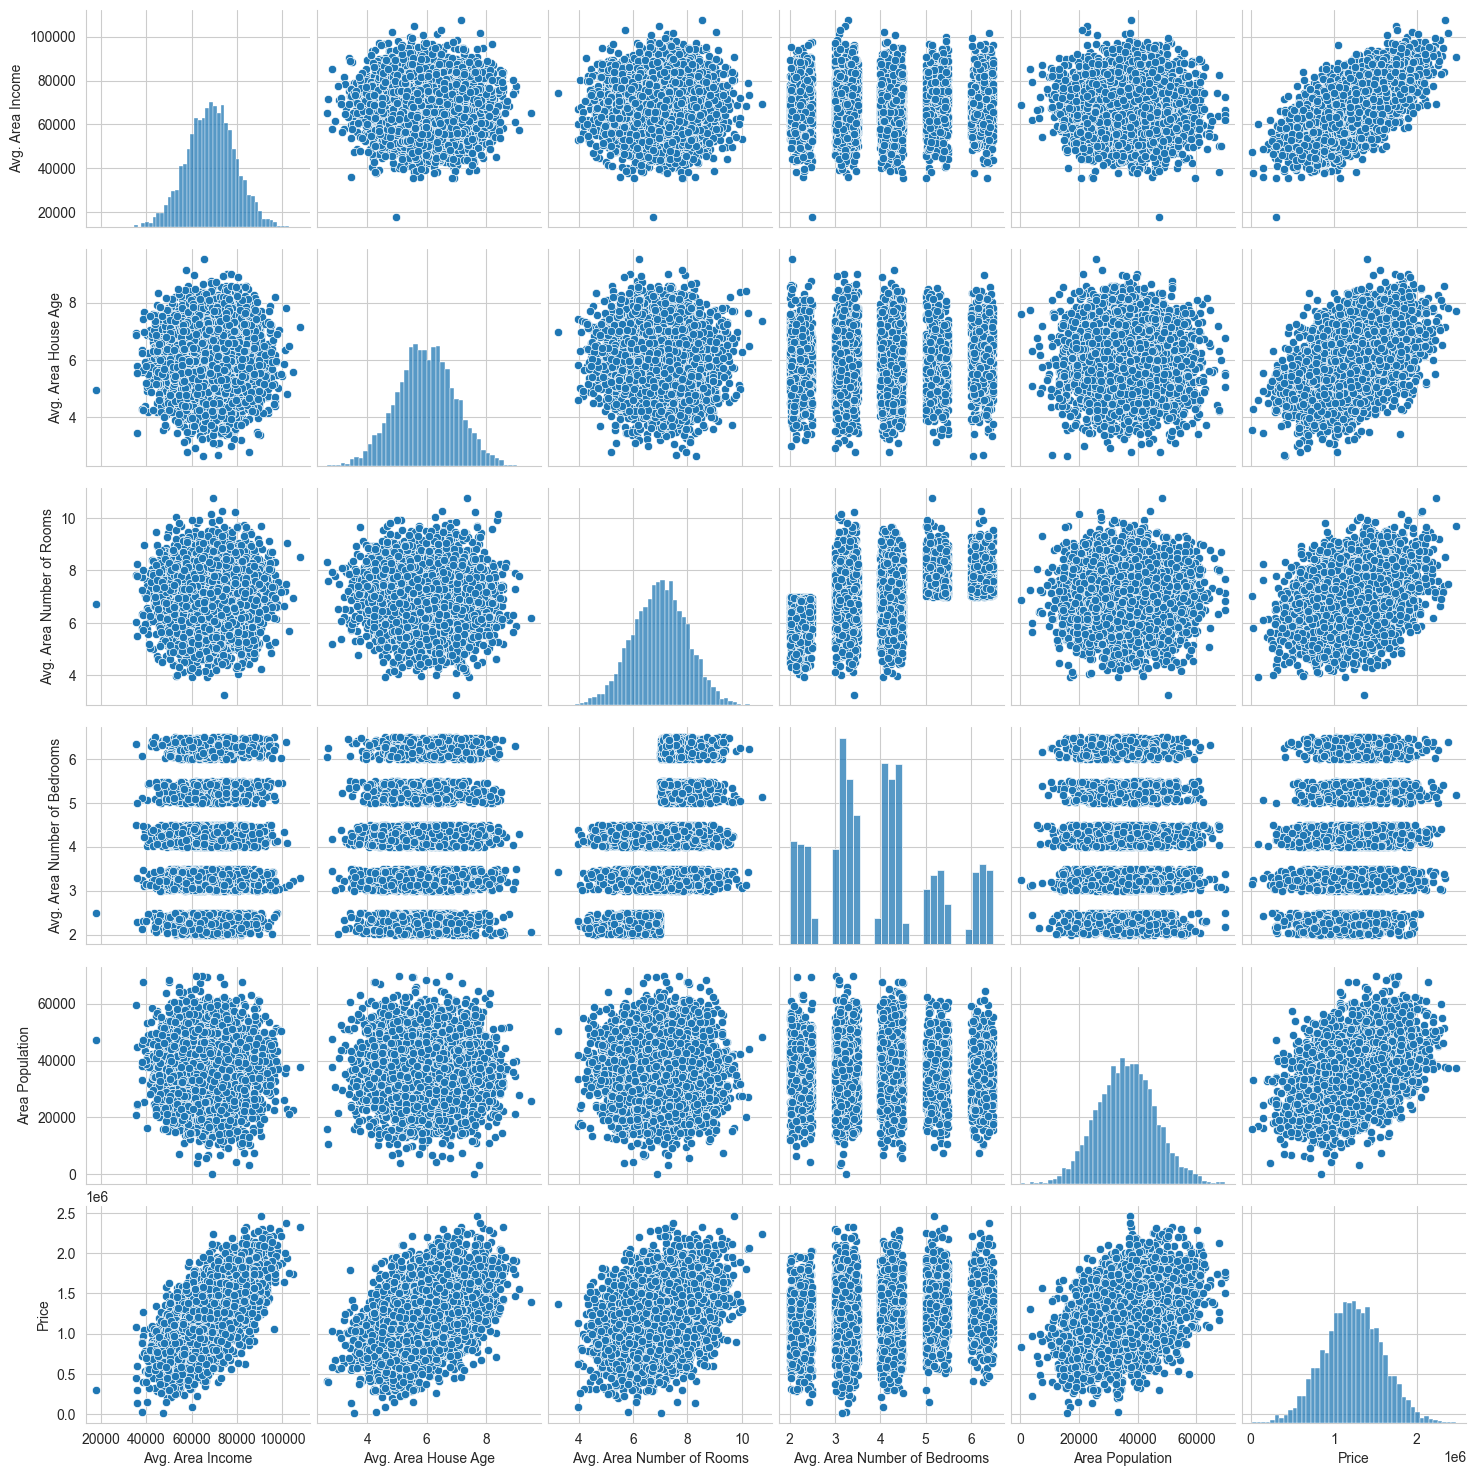

In [5]:
sns.pairplot(USA_Housing);

Cosas que se ven:
El precio que es lo que voy a estimar tiene una distribución normal, lo cual es perfecto para regresión lineal.



## **Distribution of Housing Price Across USA**

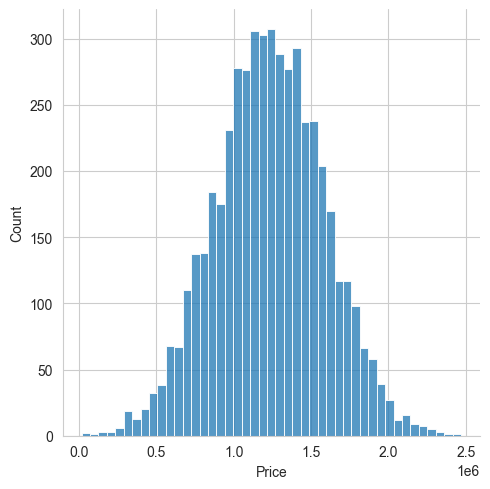

In [6]:
sns.displot(USA_Housing['Price']);

In [7]:
#Displaying correlation among all the columns 
USA_Housing.corr(numeric_only=True)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


## **Displaying correlation among all the columns using Heat Map**


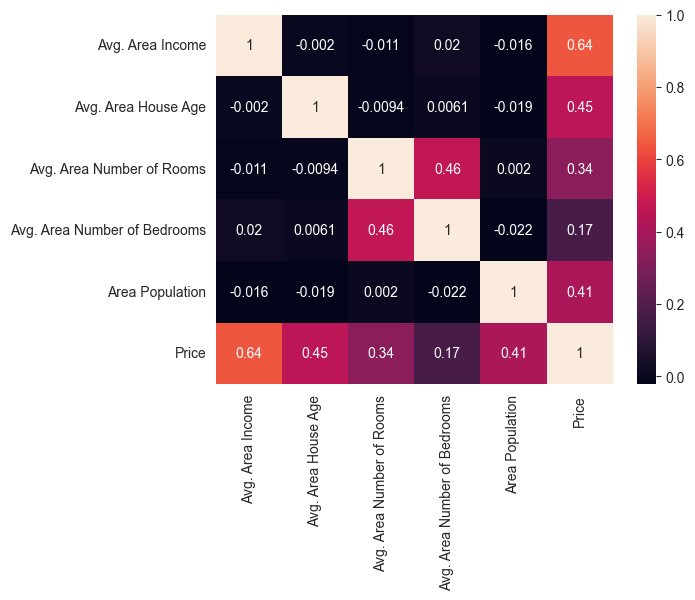

In [8]:
sns.heatmap(USA_Housing.corr(numeric_only=True), annot=True);

Número de dormitorios y número de estancias tienen mucha correlación. Quitar una. Con cual me quedo? Con la que tenga más relación con el target: en este caso con número de habitaciones

## **Training a Linear Regression Model**

[](http://)We will need to first split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column. We will toss out the Address column because it only has text info that the linear regression model can't use.

### X and y arrays

In [9]:
#Getting all Column names
USA_Housing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

y = a + b1*X + b2*X

In [ ]:
# Meto todas las columnas excepto el target y el address que está en string. Los modelos no entienden de strings, habría 
# que pasarlo a números si queremos meterlo.
# Columns as Features
X = USA_Housing[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
X

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [11]:
# Price is my Target Variable, what we trying to predict
y = USA_Housing['Price']
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [12]:
X.values

array([[7.95454586e+04, 5.68286132e+00, 7.00918814e+00, 4.09000000e+00,
        2.30868005e+04],
       [7.92486425e+04, 6.00289981e+00, 6.73082102e+00, 3.09000000e+00,
        4.01730722e+04],
       [6.12870672e+04, 5.86588984e+00, 8.51272743e+00, 5.13000000e+00,
        3.68821594e+04],
       ...,
       [6.33906869e+04, 7.25059061e+00, 4.80508098e+00, 2.13000000e+00,
        3.32661455e+04],
       [6.80013312e+04, 5.53438842e+00, 7.13014386e+00, 5.44000000e+00,
        4.26256202e+04],
       [6.55105818e+04, 5.99230531e+00, 6.79233610e+00, 4.07000000e+00,
        4.65012838e+04]], shape=(5000, 5))

In [13]:
y.values

array([1059033.55787012, 1505890.91484695, 1058987.98787608, ...,
       1030729.58315229, 1198656.87240769, 1298950.48026696],
      shape=(5000,))

## **Training the Model**

Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets.


In [14]:
# Esta función me separa los datos para hacer el training y el test. Randome_state fija la semilla para que siempre elija 
# el mismo conjunto aleatorio de datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [15]:
print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Total features shape: (5000, 5)
Train features shape: (3500, 5)
Train target shape: (3500,)
Test features shape: (1500, 5)
Test target shape: (1500,)


Teníamos 5000 registros. Ahora hay 3500 para train y 1500 para test

In [16]:
#importing the Linear Regression Algorithm
from sklearn.linear_model import LinearRegression

In [17]:
#creating LinearRegression Object
lm = LinearRegression()

In [ ]:
#Training the Data Model, le pasamos los parámetros y el target
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


 ## **Model Evaluation**


Let's evaluate the model by checking out it's coefficients 

y = a + bX1 + cX2 + dX3 + eX4 + fX5

y = -2638673 + 21.6*Avg Income + ......

In [19]:
# intercepto es la constante que no se multiplica (a)
print(lm.intercept_)

-2638673.426190405


In [ ]:
# Ver las constantes del modelo
print(lm.coef_)

[2.16257989e+01 1.65590393e+05 1.19827783e+05 2.36109526e+03
 1.52165814e+01]


In [21]:
coeff_df = pd.DataFrame(lm.coef_,
                        X.columns,
                        columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.625799
Avg. Area House Age,165590.392746
Avg. Area Number of Rooms,119827.783390
Avg. Area Number of Bedrooms,2361.095262
Area Population,15.216581


y = a + bX1 + cX2 + dX3 + eX4 + fX5

y = -2638673 + 21.6*Avg Income + ......

**Interpreting the coefficients:**

- Holding all other features fixed, a 1 unit increase in **Avg. Area Income** is associated with an **increase of \$21.62**.
- Holding all other features fixed, a 1 unit increase in **Avg. Area House Age** is associated with an **increase of \$165590.39**.
- Holding all other features fixed, a 1 unit increase in **Avg. Area Number of Rooms** is associated with an **increase of \$119827.78**.
- Holding all other features fixed, a 1 unit increase in **Avg. Area Number of Bedrooms** is associated with an **increase of \$2361.09**.
- Holding all other features fixed, a 1 unit increase in **Area Population** is associated with an **increase of \$15.21**.


## **Predictions from our Model**

Let's grab predictions off our test set and see how well it did!

In [22]:
X_test

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
1501,61907.593345,7.017838,6.440256,3.25,43828.947207
2586,57160.202243,6.893260,6.921532,3.13,43467.147035
2653,70190.796445,6.745054,6.662567,2.01,29215.136112
1055,69316.796889,6.300409,7.873576,4.28,24448.211461
705,72991.481649,3.412866,6.494081,2.48,50626.495426
...,...,...,...,...,...
3563,74208.124644,6.259782,8.666717,3.38,25507.336340
1538,71112.350296,5.612677,7.419542,4.26,24134.413996
1837,63665.394418,6.729105,7.732959,3.43,44029.681816
2380,56073.892443,6.576733,6.959056,4.40,64149.680213


In [23]:
predictions = lm.predict(X_test)
predictions

array([1308536.13592598, 1237122.72746455, 1243835.62817085, ...,
       1457119.79297219, 1483428.9530929 , 1047510.5973721 ],
      shape=(1500,))

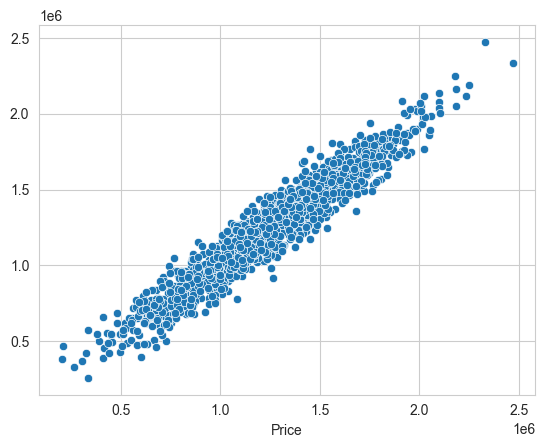

In [ ]:
# Cuanto se acerca mi modelo a la realidad. Comparo predicciones
# Parece un modelo bueno. Si fuera una línea recta sería acierto al 100% 
# Los errores están distribuidos
sns.scatterplot(x = y_test, y = predictions);

In [ ]:
# Me invento una vivienda nueva para probar. Si le entreno con x número de características tengo que pasarle ese mismo número
new_home = np.array([[100000, 20, 8, 9, 100000],
                    [200000, 40, 16, 18, 110000]])

lm.predict(new_home)

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 5337244.58691659, 11943670.27444094])

## **Residual Histogram**

**Ploting a histogram of the residuals and making sure it looks normally distributed.** If not, linear regression is nos appropiate for this analysis. Normally distribution of residuals is an assumption for Linear Regression.

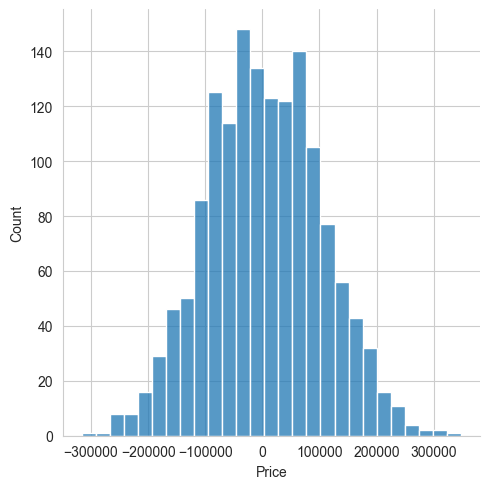

In [ ]:
# Los errores tienen que tener una distribución normal
sns.displot((y_test - predictions));

**Calculating the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error**

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [ ]:
from sklearn import metrics

lm.score(X_test, y_test) #este es el R2
# 1 es la perfección. 0.91 está bastante bien

0.9146818498754012

In [28]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 81135.56609336908
MSE: 10068422551.400915
RMSE: 100341.52954485454


#MAE y RMSE están en la misma unidad que el target

In [29]:
USA_Housing["Price"].mean()

np.float64(1232072.654142357)

## Feature importance

In [ ]:
# Cómo de importantes (influyentes) son las diferentes variables en el resultado. Aquí saco los coeficientes. Pero lo que 
# ya habíamos visto. Me da el coeficiente de la ecuación y están en unidades distintas. Para poder compararlos tengo que 
# ponerlo a la misma escala. En el caso de regresión lineal funciona igual de bien con modelos escalados que con que no
# hay otros que no.
intercept = lm.intercept_
features = pd.DataFrame(lm.coef_, X_train.columns, columns=['coefficient'])
features.head().sort_values('coefficient', ascending=False)

,coefficient
Avg. Area House Age,165590.392746
Avg. Area Number of Rooms,119827.783390
Avg. Area Number of Bedrooms,2361.095262
Avg. Area Income,21.625799
Area Population,15.216581


In [31]:
USA_Housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


y = w1.X1 + w2.X2 + w3.X3

One extra bedroom increases the price (Y) in 2300, and one extra dollar un area income increases price in 21. This is the meaning of the coefficents, bur **does it mean that the number of bedrooms is much important than the area income?**

Absolutly no. You must standarize the coefficents for better understanding the importance of each one.

In [ ]:
#X_train_scal

In [ ]:
from sklearn import preprocessing

# Para escalar, escalo sólo con el train para no darle información sobre el objetivo
std_scale = preprocessing.StandardScaler().fit(X_train) #me guardo el escalador
X_train_scal = std_scale.transform(X_train)

#Vuelvo a entrenar el modelo
lm_scal = LinearRegression()
lm_scal.fit(X_train_scal, y_train)

# Y ahora miro los coeficienteds del modelo
intercept_scal = lm_scal.intercept_
features_std = pd.DataFrame(lm_scal.coef_, X_train.columns, columns=['coefficient'])

features_std.sort_values('coefficient', ascending=False)

,coefficient
Avg. Area Income,232679.724643
Avg. Area House Age,163841.046593
Area Population,151252.342377
Avg. Area Number of Rooms,121110.555478
Avg. Area Number of Bedrooms,2892.815119


In [33]:
from sklearn import preprocessing

# Si ahora quiero pasar el test. Tengo que escalar también el test 
std_scale = preprocessing.StandardScaler()
std_scale.fit(X_train) 
X_train_scal = std_scale.transform(X_train)
X_test_scal = std_scale.transform(X_test)

lm_scal = LinearRegression()
lm_scal.fit(X_train_scal, y_train)

predictions_2 = lm_scal.predict(X_test_scal)

intercept_scal = lm_scal.intercept_
features_std = pd.DataFrame(lm_scal.coef_, X_train.columns, columns=['coefficient'])

features_std.sort_values('coefficient', ascending=False)

,coefficient
Avg. Area Income,232679.724643
Avg. Area House Age,163841.046593
Area Population,151252.342377
Avg. Area Number of Rooms,121110.555478
Avg. Area Number of Bedrooms,2892.815119


In [34]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions_2))
print('MSE:', metrics.mean_squared_error(y_test, predictions_2))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions_2)))

MAE: 81135.56609336878
MSE: 10068422551.40088
RMSE: 100341.52954485436


	coefficient

Avg. Area House Age	165590.392746

Avg. Area Number of Rooms	119827.783390

Avg. Area Number of Bedrooms	2361.095262

Avg. Area Income	21.625799

Area Population	15.216581

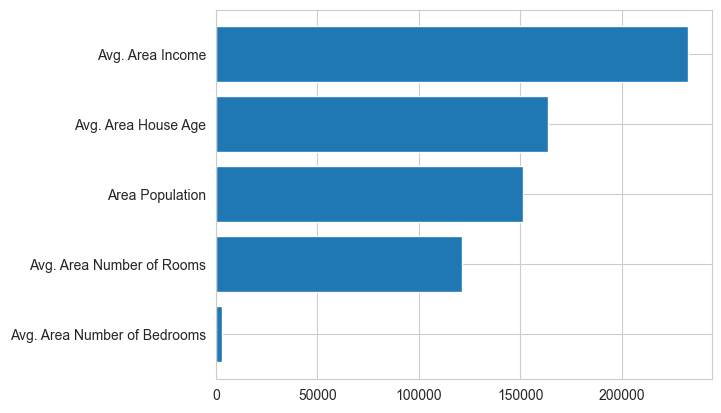

In [ ]:
# Se ven los coeficientes y comprobamos que el factor más determinante es el area income. 
import matplotlib.pyplot as plt
features_std = features_std.sort_values('coefficient', ascending=True)
plt.barh(features_std.index, features_std.coefficient);

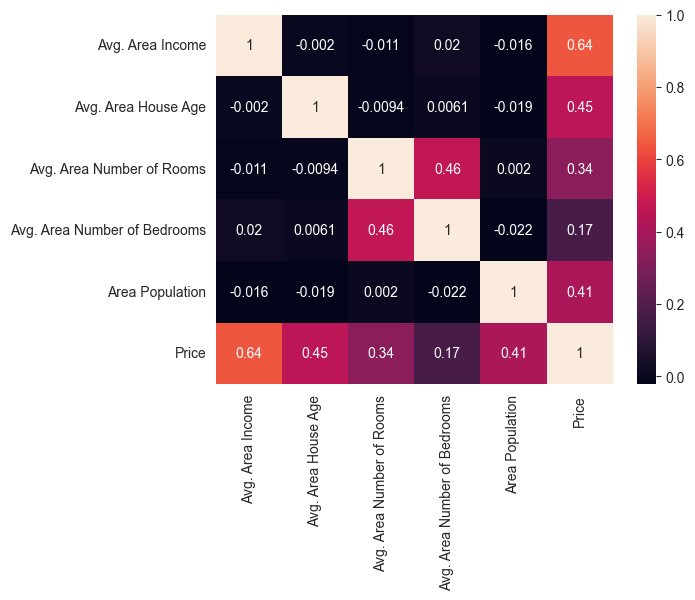

In [36]:
sns.heatmap(USA_Housing.corr(numeric_only=True), annot=True);

## Removing noise
Let's try a new model without the `Avg. Area Number of Bedrooms`

In [37]:
y_test.shape

(1500,)

In [ ]:
from sklearn import metrics

In [38]:
X = USA_Housing[['Avg. Area Income', 'Avg. Area House Age',
                 'Avg. Area Number of Rooms', 'Area Population']]

y = USA_Housing['Price']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42)

lm = LinearRegression(n_jobs=-1) 
lm.fit(X_train, y_train)

predictions = lm.predict(X_test)
predictions

# A little bit lower without Avg. Area Number of Bedrooms
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 81116.43361053737
MSE: 10062092569.298712
RMSE: 100309.98240104876


Previous model:

* MAE: 81135.56609336905


* MSE: 10068422551.401144


* RMSE: 100341.52954485567

In [ ]:
#El modelo predice igual PERO es un mejor modelo porque es más simple, necesita menos información,

In [42]:
#El MAPE me da el error en porcentaje
print('MAE:', metrics.mean_absolute_percentage_error(y_test, predictions))


MAE: 0.07335551683782678
